# 1. Restricting ligand–receptor methods with spatial proximity

Standard cell–cell communication methods — CellPhoneDB, NATMI, SingleCellSignalR, etc. and
LIANA's consensus of them — take an expression matrix and a cell-type label, and ask:
*given that cell type A expresses the ligand and cell type B the receptor, how strong
and how specific is that interaction?* They were designed for dissociated scRNA-seq,
so they know nothing about geometry: two cell types at opposite ends of the tissue
score exactly like two cell types sitting on top of each other.

Restricting inference to cell types that are actually in spatial contact is therefore
not cosmetic — it removes predictions that cannot happen
([Dimitrov et al., 2022](https://doi.org/10.1038/s41467-022-30755-0);
[Dimitrov et al., 2024](https://doi.org/10.1038/s41556-024-01469-w)).

With single-cell resolution spatial data we can do exactly that. 

Here we:

1. Measure how close each pair of cell types is (spatial proximity).
2. Run ligand–receptor (LR) analysis using expression alone as an **unconstrained** baseline.
3. Run two spatially constrained analyses: **binary filtering** and **proximity weighting**. Both approaches are explained below.
4. We then compare the three results: expression only, binary filtering, and proximity weighting, to see how spatial constraint and degree of proximity change the predictions.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import liana as li

import warnings
warnings.filterwarnings("ignore")

adata = sc.read_h5ad("../../data/brain_section.h5ad")
adata

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'cell_type_colors', 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: 'counts', None (.X)

## Cell type spatial proximity

This method finds pairwise proximity between cell types using minimum nearest-neighbor
distances in spatial coordinates (inspired by
[CellChatv2](https://www.nature.com/articles/s41596-024-01045-4)) and computes a
proximity score using a kernel function (e.g. Gaussian). <br>
Proximity scores are used for weighting ligand–receptor interactions by how strongly the
corresponding cell types co-localize across the whole slide.

Specifically, for each cell type pair $(A, B)$:

1. **Distance calculation**: Find nearest neighbor (euclidean) distances $d_i$ for each cell $i \in A$ to cells in $B$
   - For self-interactions $(A = A)$, exclude the cell itself (use 2nd nearest neighbor)

2. **Aggregation**: Compute trimmed mean distance
   $$\bar{d}_{A,B} = \text{trim\_mean}(\{d_i\}, \alpha)$$
   where $\alpha$ is the trim fraction (default: 0.1)

3. **Proximity score**: Apply kernel function (e.g. Gaussian $K(d, \sigma) = \exp\left(-\frac{d^2}{2\sigma^2}\right)$) to mean distance, where $\sigma$ is the bandwidth parameter controlling the spatial scale of proximity.
   $$p_{A,B} = K(\bar{d}_{A,B}, \sigma)$$

4. **Multiply** each ligand–receptor interaction score between cell types $A$ and $B$ by proximity score $p_{A,B}$ to get proximity-weighted interaction scores.

### What is the bandwidth?

`bandwidth` ($\sigma$) is a **distance, in the units of the spatial coordinates — microns
here**. It serves two purposes:

- It is the neighbour-distance threshold used for the `interacting` flag.
- It controls how fast the Gaussian proximity weight decreases with the mean distance.

The choice should reflect the spatial range you want to investigate. We will compare other settings in the exercise.

In [2]:
bandwidth = 30

In [3]:
pair_proximity = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian', bandwidth=bandwidth, min_cells_in_proximity = 10, spatial_key='X_spatial_coords', verbose=True)

Computing cell type proximities:   0%|          | 0/484 [00:00<?, ?it/s]

Computing cell type proximities:   1%|          | 3/484 [00:00<00:17, 27.65it/s]

Computing cell type proximities:   2%|▏         | 9/484 [00:00<00:10, 44.66it/s]

Computing cell type proximities:   3%|▎         | 16/484 [00:00<00:08, 55.32it/s]

Computing cell type proximities:   5%|▍         | 22/484 [00:00<00:08, 56.87it/s]

...

Computing cell type proximities:  95%|█████████▌| 460/484 [00:07<00:00, 70.52it/s]

Computing cell type proximities:  97%|█████████▋| 468/484 [00:07<00:00, 70.76it/s]

Computing cell type proximities:  98%|█████████▊| 476/484 [00:07<00:00, 67.59it/s]

Computing cell type proximities: 100%|█████████▉| 483/484 [00:07<00:00, 59.95it/s]

Computing cell type proximities: 100%|██████████| 484/484 [00:07<00:00, 60.81it/s]

The proximity table below contains two useful outputs:

| Output | Meaning |
|---|---|
| `interacting` | A 1/0 (binary) flag: do at least 10 source cells have a target neighbour within the chosen distance? **1** if yes, and **0** otherwise. |
| `proximity` | is a spatial co-localization weight between two cell types, bound between 0 and 1. Higher values mean the two cell types sit closer together; lower values reflect weaker or no spatial co-localization. |

The weight LIANA actually applies to LR scores is `proximity × interacting`, so the heatmap below shows that product (dots mark `interacting == 1`).

In [4]:
pair_proximity.sort_values('proximity', ascending=True).head(3)

,source,target,mean_distance,interacting,proximity
234,histaminergic neuron,neuroblast (sensu Vertebrata),1506.719460,0,0.0
167,ependymal cell,monocyte,1402.563690,0,0.0
419,smooth muscle cell,cholinergic neuron,3877.382295,0,0.0


<Axes: xlabel='target', ylabel='source'>

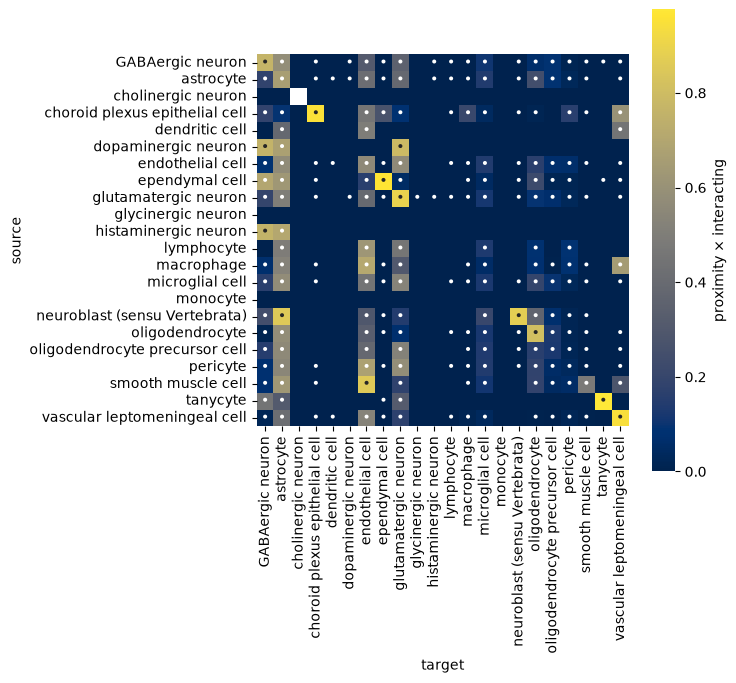

In [5]:
# the weight actually applied to LR scores: proximity, zeroed where `interacting == 0`
pair_proximity['weight'] = pair_proximity['proximity'] * pair_proximity['interacting']

plt.figure(figsize=(6, 6))
sns.heatmap(
    data=pair_proximity.pivot(index='source', columns='target', values='weight'),
    annot=pair_proximity.pivot(index='source', columns='target', values='interacting').fillna(0).astype(int).replace({1: '•', 0: ''}),
    fmt='',
    annot_kws={'fontfamily': 'DejaVu Sans'},
    cmap='cividis',
    square=True,
    cbar_kws={'label': 'proximity × interacting'}
)

The heatmap indicates that e.g. the **smooth muscle cell** and **tanycyte** pair did not
meet the interaction criteria (`interacting == 0`). The spatial plot below shows why:
smooth muscle cells (n = 397) are scattered along vessels across the section, whereas
tanycytes (n = 182) are confined to the wall of the third ventricle, so too few smooth
muscle cells have a tanycyte within range to pass the filter.

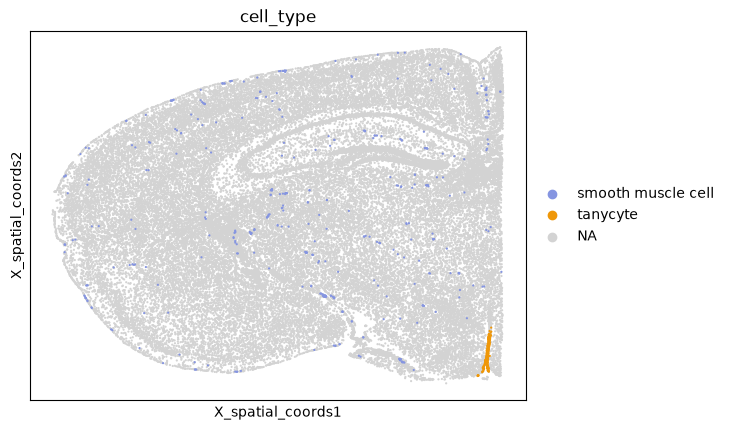

In [6]:
sc.pl.embedding(
    adata,
    basis="X_spatial_coords",
    color="cell_type",
    groups=["smooth muscle cell", "tanycyte"],
    s=10,
)

## Expression-only vs. spatially constrained CCC analysis

We will compare three analyses on the same data: expression only, hard filtering, and proximity weighting. We will follow the same interactions across the three results to see how spatial constraint and degree of proximity change the predictions.

LIANA runs several expression-based LR methods and combines their rankings using `li.mt.rank_aggregate`. We first run it without cell locations to get the unconstrained (expression-only) baseline.

Two settings matter here. `min_cells=20` drops cell types with fewer than 20 cells
(histaminergic, dopaminergic, glycinergic and cholinergic neurons, monocytes): with a handful
of cells, a few cells' expression can put a pair at the very top of the ranking.
`expr_prop=0.01` is deliberately permissive (the default is 0.1) because single genes are
sparse in a targeted MERFISH panel; it keeps ~20,800 rows instead of ~1,700 so we can follow
an interaction across all cell type pairs, and leaves the top of the ranking essentially unchanged.

*Tip:* the human `consensus` resource uses human gene symbols, so for mouse data use
`resource_name='mouseconsensus'`.

<img src="../../figures/lr_spatial_restriction.png" width=1200 />

In [7]:
# (a) the standard, non-spatial run -- what you would get from dissociated scRNA-seq
li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     min_cells=20,
                     use_raw=False,
                     verbose=True,
                     key_added='liana_res_plain',
                     )

Using resource `mouseconsensus`.


Using `.X`!


0.83 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 51499 samples and 113 features


Assuming that counts were `natural` log-normalized!


...

 75%|███████▌  | 750/1000 [00:01<00:00, 389.67it/s]

100%|██████████| 1000/1000 [00:02<00:00, 438.17it/s]

100%|██████████| 1000/1000 [00:02<00:00, 421.02it/s]

Running Connectome
Running log2FC
Running NATMI


Running SingleCellSignalR


<div style="border-left:5px solid #f9a825; background:#fffde7; padding:10px 14px; border-radius:4px; margin:12px 0;">

**⚠️ Keep in mind:** the log line above says that 83% of the entities in the resource
are missing from the data. A ~1,120-gene MERFISH panel lets us test only a limited set of LR
pairs — an interaction that is absent from the results was not tested, which is not the same
as not communicating.
</div>

## Include cell locations

### (i) Hard restriction -  microenvironments

We pass cell-type pairs with `interacting = 1` to LIANA through the `groupby_pairs` parameter. Other pairs are excluded from this run. This filter defines which cell type pairs are close enough to signal.

`groupby_pairs` takes any list of source/target pairs, so the restriction does not have to
come from spatial data at all — prior knowledge of how a tissue is organised does the same
job. That is what a [CellPhoneDBv3](https://doi.org/10.1038/s41588-021-00972-2) *microenvironment* idea is. Either way it is a coarse
instrument: one decision per cell type pair for the whole section, which says nothing
about *where* or *at what distance* an interaction happens. Notebooks 02 and 03 take that up.

In [8]:
microenv = pair_proximity.query("interacting == 1")[["source", "target"]]
print(f"{len(microenv)}/{len(pair_proximity)} cell type pairs kept")

li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     groupby_pairs=microenv,
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     min_cells=20,
                     use_raw=False,
                     verbose=True,
                     key_added='liana_res_micro',
                     )

Using resource `mouseconsensus`.


224/483 cell type pairs kept


Using `.X`!


0.83 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 51499 samples and 113 features
Assuming that counts were `natural` log-normalized!


...

 50%|█████     | 500/1000 [00:00<00:00, 540.16it/s]

 75%|███████▌  | 750/1000 [00:01<00:00, 499.18it/s]

100%|██████████| 1000/1000 [00:02<00:00, 485.33it/s]

100%|██████████| 1000/1000 [00:02<00:00, 498.58it/s]

Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


### (ii) Proximity weighting — account for how close pairs are

Here, we use proximity to weight the predictions. Pairs that fail the binary criterion receive zero spatial weight. Eligible pairs receive a weight based on their trimmed mean distance: closer pairs receive larger weights.
To do this, we pass `spatial_key` so every score is multiplied by the pair's proximity, as in [CellChatv2](https://doi.org/10.1038/s41596-024-01045-4).

In [9]:
# (b) the same run, restricted by how close the cell types actually are
li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     spatial_key='X_spatial_coords',
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     min_cells=20,
                     use_raw=False,
                     verbose=True,
                     spatial_kwargs={'kernel':'gaussian', 'bandwidth':bandwidth},
                     )

Using resource `mouseconsensus`.


Using `.X`!


0.83 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 51499 samples and 113 features
Assuming that counts were `natural` log-normalized!


Computing cell type proximities:   0%|          | 0/289 [00:00<?, ?it/s]

...

 50%|█████     | 500/1000 [00:00<00:00, 617.77it/s]

 75%|███████▌  | 750/1000 [00:01<00:00, 594.73it/s]

100%|██████████| 1000/1000 [00:01<00:00, 615.04it/s]

100%|██████████| 1000/1000 [00:01<00:00, 614.13it/s]

Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [10]:
adata.uns["liana_res"].sort_values(['magnitude_rank', 'lrscore'], ascending=(True, False)).head(3)

,source,target,ligand_complex,receptor_complex,ligand,receptor,ligand_means,receptor_means,ligand_props,receptor_props,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
2936,choroid plexus epithelial cell,choroid plexus epithelial cell,Col18a1,Gpc4,Col18a1,Gpc4,2.437379,2.068153,0.599462,0.534946,2.146037,0.0,4.802052,1.240374,1.892468,0.030607,0.799418,4.253133e-07,1.442911e-11
17190,smooth muscle cell,endothelial cell,Spp1,S1pr1,Spp1,S1pr1,0.826665,4.161777,0.206549,0.826147,2.140116,0.0,2.951961,0.745659,1.294466,0.010335,0.696465,1.374939e-06,1.174102e-09
19300,tanycyte,tanycyte,Rspo3,Lgr6,Rspo3,Lgr6,1.298664,2.392321,0.346154,0.582418,1.801758,0.0,3.033196,1.926462,3.122130,0.172551,0.784736,2.236251e-10,2.183416e-09


### What changes when we include location constraints?
We now inspect the highest-ranked expression-only candidates that were excluded by the hard filter and check their ranking scores in the weighted run.


In [11]:
keys = ["source", "target", "ligand_complex", "receptor_complex"]

def positions(key, name):
    df = adata.uns[key][keys + ["magnitude_rank"]].copy()
    df[name] = df["magnitude_rank"].rank(method="first").astype(int)
    return df.drop(columns="magnitude_rank")

cmp = (positions("liana_res_plain", "pos_plain")
       .merge(positions("liana_res_micro", "pos_micro"), on=keys, how="left")
       .merge(adata.uns["liana_res"][keys + ["magnitude_rank"]], on=keys, how="left")
       .rename(columns={"magnitude_rank": "mrank_soft"}))

print(f"{len(cmp)} interactions unconstrained; "
      f"{int(cmp['pos_micro'].notna().sum())} survive the microenvironment filter\n")

removed = cmp[cmp["pos_micro"].isna()]
print("Best-ranked interactions that proximity removes:")
print(removed.nsmallest(5, "pos_plain")[keys + ["pos_plain", "mrank_soft"]].to_string(index=False))


20756 interactions unconstrained; 15656 survive the microenvironment filter

Best-ranked interactions that proximity removes:
                        source                         target ligand_complex receptor_complex  pos_plain  mrank_soft
              endothelial cell                       tanycyte            Fn1             Tshr          7         1.0
                dendritic cell oligodendrocyte precursor cell            Fn1            Itga9         10         1.0
            smooth muscle cell                     lymphocyte            Fn1            Cd79a         13         1.0
                dendritic cell                microglial cell            Fn1            Itga9         14         1.0
choroid plexus epithelial cell oligodendrocyte precursor cell        Sostdc1             Lrp4         15         1.0


Interactions that the unconstrained run ranks near the top (the best removed one sits at
position 7) involve cell types that **do not co-localize spatially on this section**. The hard
filter removes them; the soft run keeps them but assigns the worst possible aggregate rank
(`mrank_soft == 1`). Their expression evidence is identical in both cases, which is exactly the
failure mode a non-spatial method cannot see.

Notice who they involve: tanycytes (182 cells, confined to the ventricle wall), dendritic cells
(20) and lymphocytes (48). `interacting` needs at least 10 source cells within range of the target,
which a small or tightly localised population rarely reaches, so the filter falls hardest on rare
types. With the default `min_cells=5` the unconstrained ranking is even more exposed: `Hdc → Hrh3`
among just 14 histaminergic neurons takes rank 1.

<div style="border-left:5px solid #f9a825; background:#fffde7; padding:10px 14px; border-radius:4px; margin:12px 0;">

**⚠️ Keep in mind:**

- `groupby_pairs` does not change the statistics of the rows it keeps: `cellphone_pvals` are
  identical for the interactions both runs share. Ranks in the hard run shift because the rank
  aggregation is recomputed over fewer rows. In the soft run a large fraction of interactions
  saturate at the worst rank, so *positions* within that block are ties and not interpretable.
- Proximity is not communication: two cell types being close says nothing about whether they
  signal. The labels are themselves inferred — they come from label transfer from a scRNA-seq
  reference, and 29% of cells here have `high_quality_transfer == False`.
- In the brain the hard filter may be failing here, not succeeding. Neuromodulators and
  neuropeptides — histamine (`Hdc → Hrh3`), `Penk`, `Pdyn` — act through long-range axonal
  projections and volume transmission, so a sender far from its receiver on this section can
  still signal to it.
</div>

### Visualise the proximity-weighted result

Interactions from **glutamatergic neurons** to various target cell types, ranked by
**specificity** — how much a cell type pair stands out against the rest — with colour
showing magnitude (`lr_means`). Both are proximity-weighted here.

`inverse_size=True` plots $-\log_{10}$ of the rank, so **bigger dots are more specific**
even though the legend keeps the `specificity_rank` name: 5 on that scale means $p \approx
10^{-5}$, and 0 means $p \approx 1$.


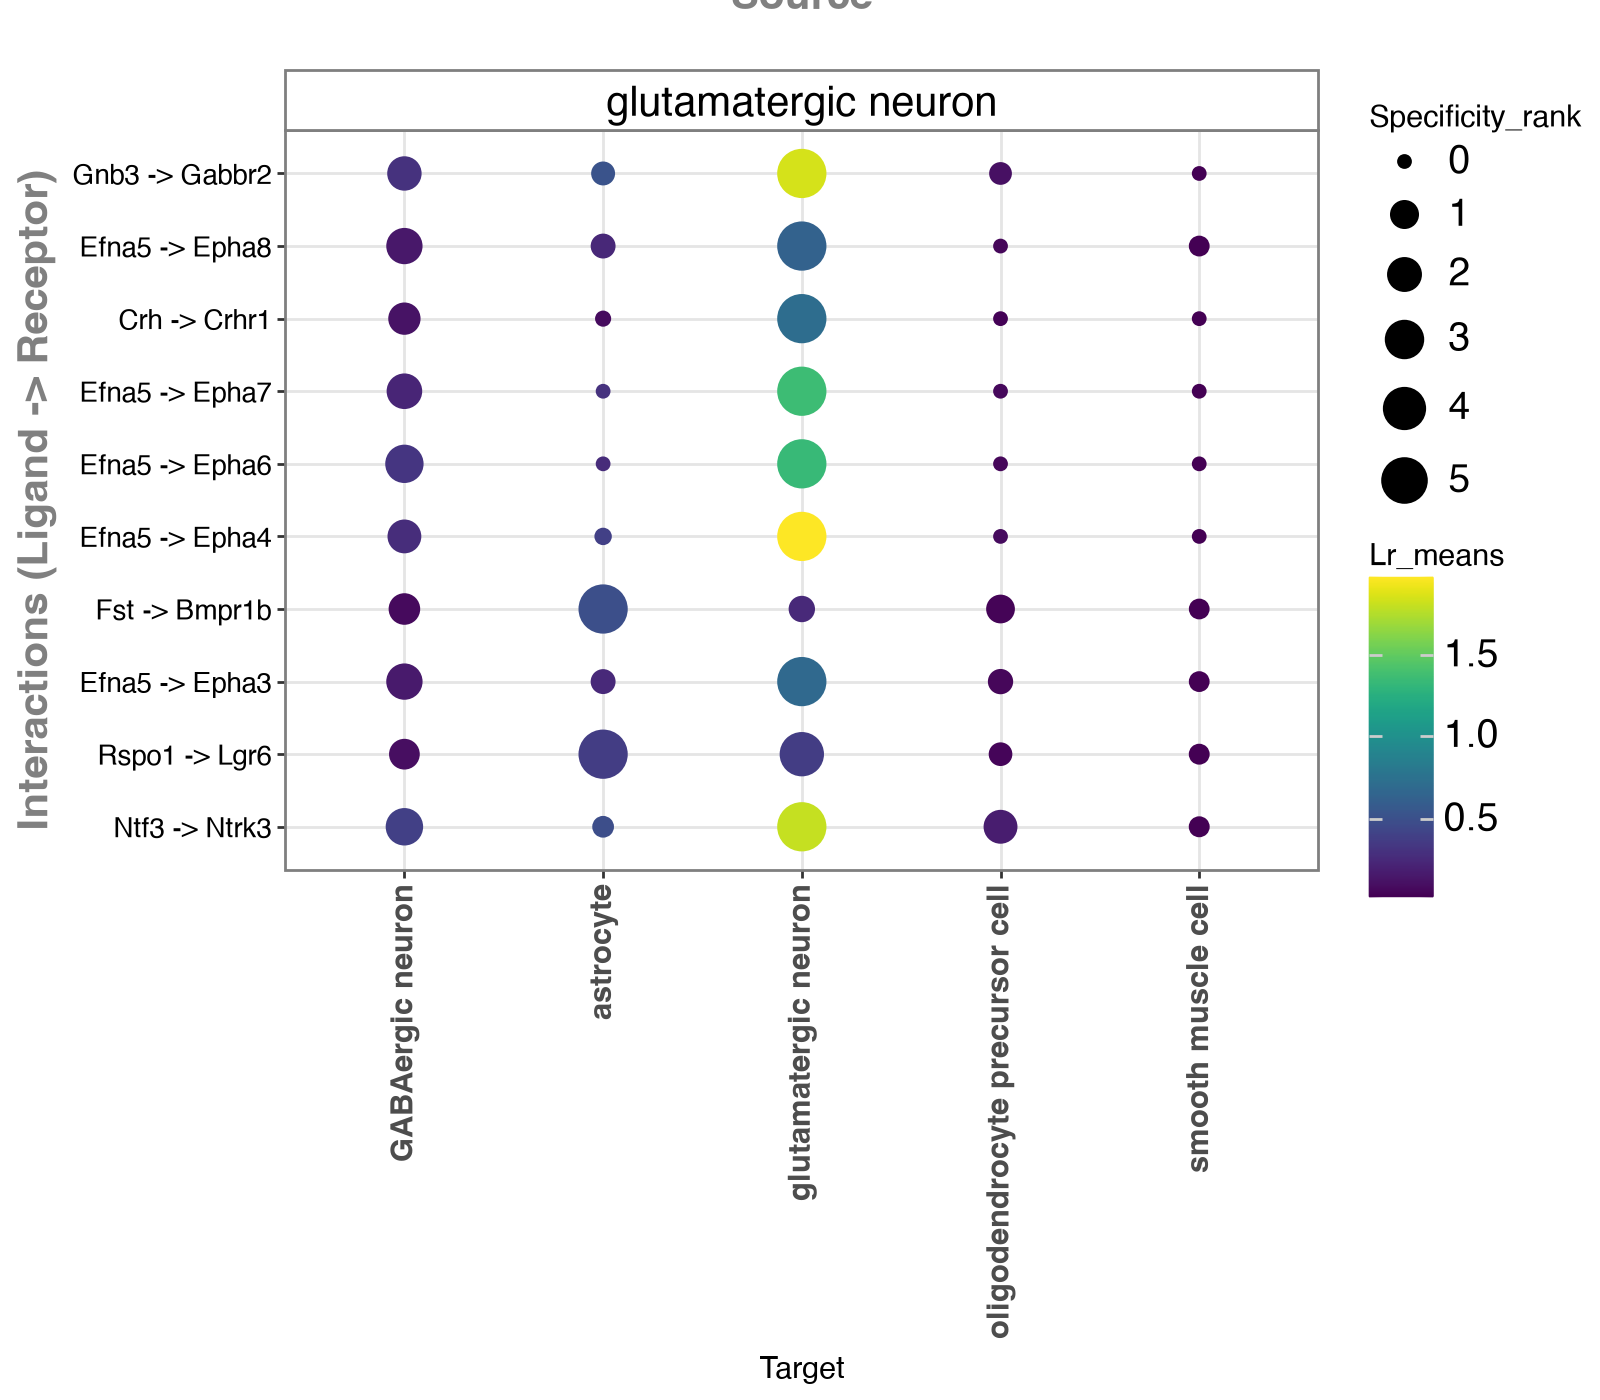

In [12]:
li.pl.dotplot(adata = adata,
              colour='lr_means',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=["glutamatergic neuron"],
              target_labels=["glutamatergic neuron", "GABAergic neuron", "astrocyte", "oligodendrocyte precursor cell", "smooth muscle cell"],
              top_n=10,
              orderby='specificity_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )


The same interaction (`Ntf3 → Ntrk3`) under all three runs, on a shared colour scale.

**Grey** cells were removed by the hard filter. **Dark** cells in the soft panel are a
different thing — still scored, but multiplied by a small proximity: of the 172 non-zero
cells, 144 keep less than half of their unconstrained score. That grading is what the soft
variant adds over the hard one. At $\sigma = 30$ µm the panel is mostly dark: the median cell
type pair on this section sits ~250 µm apart, more than eight bandwidths.

The two runs do not agree exactly: 57 cells are grey, but 66 are zero in the soft panel.
The 9 cell type pairs responsible (mostly towards choroid plexus epithelial cells) pass
`interacting` — a **local** test, at least `min_cells_in_proximity` cells within one
bandwidth — yet their **trimmed mean** distance is over a millimetre, so the Gaussian returns
zero.

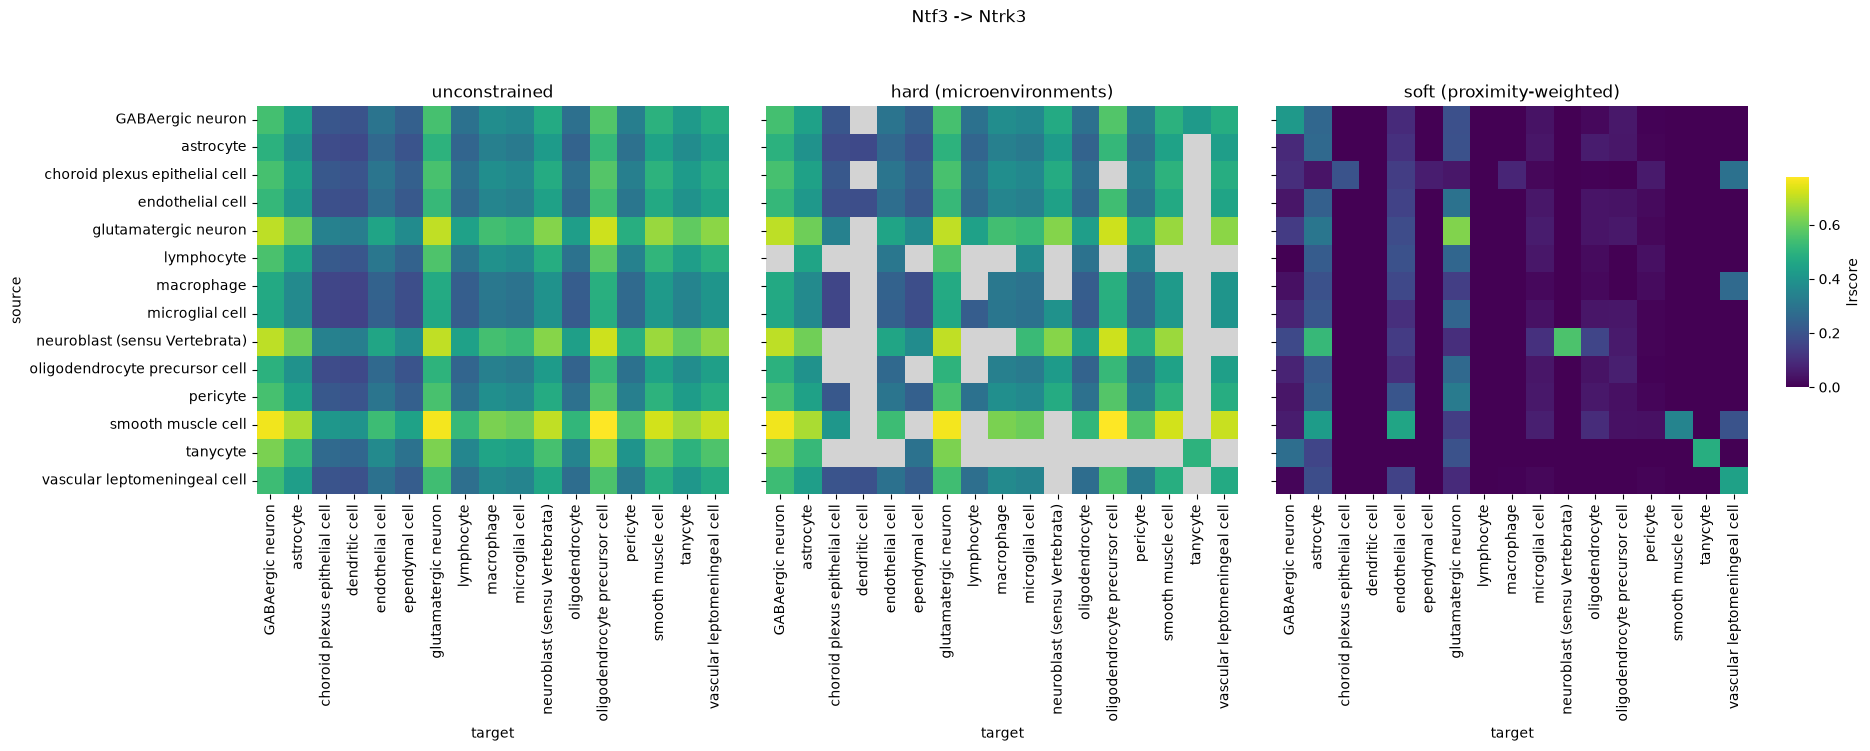

In [13]:
runs = [("liana_res_plain", "unconstrained"),
        ("liana_res_micro", "hard (microenvironments)"),
        ("liana_res", "soft (proximity-weighted)")]

mats = {}
for key, _ in runs:
    d = adata.uns[key]
    d = d[(d['ligand_complex'] == 'Ntf3') & (d['receptor_complex'] == 'Ntrk3')]
    mats[key] = d.pivot_table(index='source', columns='target', values='lrscore')

sources = sorted(set().union(*[m.index for m in mats.values()]))
targets = sorted(set().union(*[m.columns for m in mats.values()]))
vmax = max(m.max().max() for m in mats.values())

fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)
fig.subplots_adjust(right=0.91, wspace=0.08)
cbar_ax = fig.add_axes((0.93, 0.35, 0.012, 0.35))

for ax, (key, title) in zip(axes, runs):
    sns.heatmap(mats[key].reindex(index=sources, columns=targets),
                ax=ax, cmap='viridis', vmin=0, vmax=vmax, square=True,
                cbar=(key == runs[-1][0]), cbar_ax=cbar_ax,
                cbar_kws={'label': 'lrscore'})
    ax.set_facecolor('lightgrey')   # grey = cell type pair not scored at all
    ax.set_title(title)
    ax.set_ylabel('source' if ax is axes[0] else '')

fig.suptitle('Ntf3 -> Ntrk3')
plt.show()


---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 1 — How much does the bandwidth matter?**

`bandwidth=30` (µm) decides how quickly proximity decays with distance — and therefore
which cell type pairs count as interacting at all.

Re-run `li.pp.spatial_pair_proximity` with `bandwidth=100` and `bandwidth=300`, and count
how many cell type pairs are flagged `interacting == 1` and the median `proximity` in each case.

Which bandwidth would you defend for a MERFISH brain section, and on what grounds?
</div>

In [14]:
for bw in [30, 100, 300]:
    pp = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian',
                                      bandwidth=bw, spatial_key='X_spatial_coords')
    # ... how many pairs are interacting? what is the median proximity?
    print(bw)

30


100


300


<details>
<summary><b>Solution</b></summary>

```python
for bw in [30, 100, 300]:
    pp = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian',
                                      bandwidth=bw, spatial_key='X_spatial_coords')
    print(f"bandwidth={bw:>4} µm | interacting pairs: {int(pp['interacting'].sum()):>3}/{len(pp)}"
          f" | median proximity: {pp['proximity'].median():.3f}")
```

Interacting pairs go from 224 → 293 → 337 of 483, and the median proximity from 0.00 →
0.04 → 0.70. A small bandwidth admits only cell types that sit right next to each other; a
large one admits most pairs with similar weights, so the weighting stops discriminating.

There is no single correct answer: the bandwidth should reflect the **signalling range you
care about**, not the size of the tissue. We use `30` µm for short-range signalling; larger
values also let in cell types from different anatomical compartments.

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 2 — Follow your own interaction**

Pick a different ligand–receptor pair, or a different sender cell type, from the ranked
table, copy the `Ntf3 -> Ntrk3` heatmap cell and change the ligand and receptor.

```python
adata.uns["liana_res"].sort_values("magnitude_rank").head(20)
```

Does your interaction look plausible given the proximity heatmap from earlier — i.e. are
its top cell type pairs ones that actually co-localize?
</div>

In [15]:
# your turn
adata.uns["liana_res"].sort_values("magnitude_rank").head(20)

,source,target,ligand_complex,receptor_complex,ligand,receptor,ligand_means,receptor_means,ligand_props,receptor_props,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
2936,choroid plexus epithelial cell,choroid plexus epithelial cell,Col18a1,Gpc4,Col18a1,Gpc4,2.437379,2.068153,0.599462,0.534946,2.146037,0.0,4.802052,1.240374,1.892468,0.030607,0.799418,4.253133e-07,1.442911e-11
17190,smooth muscle cell,endothelial cell,Spp1,S1pr1,Spp1,S1pr1,0.826665,4.161777,0.206549,0.826147,2.140116,0.0,2.951961,0.745659,1.294466,0.010335,0.696465,1.374939e-06,1.174102e-09
19300,tanycyte,tanycyte,Rspo3,Lgr6,Rspo3,Lgr6,1.298664,2.392321,0.346154,0.582418,1.801758,0.0,3.033196,1.926462,3.122130,0.172551,0.784736,2.236251e-10,2.183416e-09
7697,glutamatergic neuron,glutamatergic neuron,Efna5,Epha4,Efna5,Epha4,0.827721,3.628039,0.241719,0.766125,1.996274,0.0,2.690816,0.434187,1.744554,0.026613,0.717811,1.374939e-06,2.188949e-09
20740,vascular leptomeningeal cell,vascular leptomeningeal cell,Spp1,S1pr1,Spp1,S1pr1,2.544028,1.270747,0.526579,0.317699,1.799179,0.0,3.049413,1.071234,1.682782,0.010676,0.761124,1.374939e-06,2.618926e-09
20703,vascular leptomeningeal cell,vascular leptomeningeal cell,Fn1,Tnfrsf11b,Fn1,Tnfrsf11b,3.951031,0.615463,0.701063,0.153846,2.153716,0.0,2.293761,1.128538,2.571608,0.041532,0.739281,5.629252e-08,4.949184e-09
19253,tanycyte,tanycyte,Efna5,Ephb1,Efna5,Ephb1,2.074634,1.525824,0.543956,0.406593,1.757567,0.0,3.090508,0.760847,1.246294,0.043157,0.786174,1.095494e-06,5.676028e-09
20686,vascular leptomeningeal cell,vascular leptomeningeal cell,Dcn,Egfr,Dcn,Egfr,2.632585,1.035739,0.572233,0.263290,1.730108,0.0,2.571985,1.348629,2.586000,0.025942,0.748284,1.065440e-06,6.485747e-09
20702,vascular leptomeningeal cell,vascular leptomeningeal cell,Fn1,Itga9,Fn1,Itga9,3.951031,0.466051,0.701063,0.121326,2.083248,0.0,1.736918,0.718703,1.277598,0.004995,0.716178,5.732981e-06,2.493350e-08
9974,macrophage,endothelial cell,Spp1,S1pr1,Spp1,S1pr1,1.315296,4.161777,0.281915,0.826147,1.934186,0.0,3.866178,0.795026,1.754243,0.013535,0.596570,1.374939e-06,8.868794e-08


<details>
<summary><b>Solution</b></summary>

Any well-ranked pair works. Because every score was multiplied by `proximity`, a highly
ranked interaction *cannot* involve a cell type pair with a weight near zero — so the top of
this table only contains pairs that are bright in the `proximity × interacting` heatmap. That
holds by construction; it is not a validation. Note also that most of the top 20 are
self-pairs (A → A), which get a high proximity almost by default.

A more informative check: take a top hit from `liana_res_plain` and see where it ends up in
the proximity-weighted ranking.

</details>


---

## References

- Dimitrov et al. (2022) Comparison of methods and resources for cell-cell communication
  inference from single-cell RNA-Seq data. *Nature Communications* 13:3224.
  [doi:10.1038/s41467-022-30755-0](https://doi.org/10.1038/s41467-022-30755-0)
- Dimitrov et al. (2024) LIANA+ provides an all-in-one framework for cell–cell
  communication inference. *Nature Cell Biology* 26:1613–1622.
  [doi:10.1038/s41556-024-01469-w](https://doi.org/10.1038/s41556-024-01469-w)
- Garcia-Alonso et al. (2021) Mapping the temporal and spatial dynamics of the human
  endometrium in vivo and in vitro. *Nature Genetics* 53:1698–1711 — CellPhoneDBv3
  microenvironments. [doi:10.1038/s41588-021-00972-2](https://doi.org/10.1038/s41588-021-00972-2)
- Jin et al. (2024) CellChat for systematic analysis of cell–cell communication from
  single-cell transcriptomics. *Nature Protocols* — CellChatv2, spatially informed
  inference. [doi:10.1038/s41596-024-01045-4](https://doi.org/10.1038/s41596-024-01045-4)

---

**Next:** notebook 02 asks a more detailed question — not only which interactions are plausible given proximity and expression, but also *at what distance* a given interaction is enriched.